# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Akhil Kumar T A  
**Student ID:** 2024ac05446

**Student Name:** Nakul Ramanathan  
**Student ID:** 2024ac05356  

**Student Name:** Sahoo Nishitha Ranjan  
**Student ID:** 2024ac05298

**Student Name:** Ankit Singh
**Student ID:** 2024ac0566


**Date:** 28 Dec 2025

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

np.random.seed(42)


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [ ]:

# Load Breast Cancer Wisconsin (Original) dataset from local file

problem_type = "binary_classification"

dataset_name = "Breast Cancer Wisconsin (Original)"
dataset_source = "UCI Machine Learning Repository"
problem_type = "binary_classification"
dataset_name = "Breast Cancer Wisconsin (Original)"

problem_statement = (
    "The objective of this project is to build a machine learning model that can accurately "
    "classify breast cancer tumors as malignant or benign using diagnostic features from the "
    "Breast Cancer Wisconsin dataset. Early and accurate classification is critical in medical "
    "applications to reduce false negatives and improve patient outcomes. Both a baseline "
    "logistic regression model and a multi-layer perceptron (MLP) were implemented from scratch "
    "to compare performance, learning behavior, and computational cost."
)


column_names = [
    "id",
    "clump_thickness",
    "cell_size_uniformity",
    "cell_shape_uniformity",
    "marginal_adhesion",
    "epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    header=None,
    names=column_names,
    na_values="?"
)

print("Initial shape:", df.shape)
df.head()


Initial shape: (699, 11)


,id,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [ ]:

# Check and handle missing values
print(df.isnull().sum())

df.dropna(inplace=True)
print("Shape after dropping missing values:", df.shape)


id                        0
clump_thickness           0
cell_size_uniformity      0
cell_shape_uniformity     0
marginal_adhesion         0
epithelial_cell_size      0
bare_nuclei              16
bland_chromatin           0
normal_nucleoli           0
mitoses                   0
class                     0
dtype: int64
Shape after dropping missing values: (683, 11)


In [ ]:

# Drop ID column
df.drop(columns=["id"], inplace=True)

# Features and target
X = df.drop(columns=["class"]).values
y = df["class"].values

# Convert labels: 2 -> 0 (Benign), 4 -> 1 (Malignant)
y = np.where(y == 4, 1, 0)

# Normalize
X = (X - X.mean()) / (X.std() + 1e-8)

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))




X shape: (683, 9)
y distribution: [444 239]



### Problem Statement

This dataset predicts whether a tumor is malignant or benign using diagnostic measurements.
This is a **binary classification** problem with **683 samples** obtained from the UCI ML Repository.

**Recall** is used as the primary evaluation metric because false negatives (missing cancer)
are more dangerous than false positives.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

n_samples = X.shape[0]
n_features = X.shape[1]


primary_metric = "Recall"

metric_justification = (
    "Recall is chosen as the primary evaluation metric because, in medical diagnosis problems, "
    "false negatives are more dangerous than false positives. Missing a malignant tumor can have "
    "severe consequences, so maximizing the model’s ability to correctly identify positive cases "
    "is critical."
)

# Train-test split information
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
train_test_ratio = round(train_samples / (train_samples + test_samples), 2)



Train shape: (546, 9)
Test shape: (137, 9)


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- **Logistic Regression (for binary classification)**
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [ ]:
def accuracy_score(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            correct += 1
    return correct / len(y_true)


def precision_score(y_true, y_pred):
    tp = 0
    fp = 0
    for yt, yp in zip(y_true, y_pred):
        if yp == 1:
            if yt == 1:
                tp += 1
            else:
                fp += 1
    if tp + fp == 0:
        return 0
    return tp / (tp + fp)


def recall_score(y_true, y_pred):
    tp = 0
    fn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1:
            if yp == 1:
                tp += 1
            else:
                fn += 1
    if tp + fn == 0:
        return 0
    return tp / (tp + fn)


def f1_score(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

In [ ]:



class BaselineModel:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    #Stochastic Gradient Descent used for trainig
    def fit(self, X, y):
      m, n = X.shape
      self.w = np.zeros(n)
      self.b = 0

      for epoch in range(self.n_iterations):

          # Shuffle data at the start of each epoch
          indices = np.random.permutation(m)
          X_shuffled = X[indices]
          y_shuffled = y[indices]

          epoch_loss = 0

          for i in range(m):
              x_i = X_shuffled[i]
              y_i = y_shuffled[i]

              # Forward pass
              z = np.dot(x_i, self.w) + self.b
              y_hat = self.sigmoid(z)

              #so as to avoid log(0) = infinity in the later steps
              y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8)

              # Loss
              loss = -(y_i * np.log(y_hat) + (1 - y_i) * np.log(1 - y_hat))
              epoch_loss += loss

              # Gradients (SGD update)
              dw = (y_hat - y_i) * x_i
              db = (y_hat - y_i)

              # Parameter update
              self.w -= self.lr * dw
              self.b -= self.lr * db

          # Average loss per epoch
          self.loss_history.append(epoch_loss / m)

      return self

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        return (self.sigmoid(z) >= 0.5).astype(int)


In [ ]:


# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel()
baseline_model.fit(X_train, y_train)
#baseline.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test)



baseline_training_time = time.time() - baseline_start
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

# Store loss explicitly
baseline_initial_loss = baseline_model.loss_history[0]
baseline_final_loss = baseline_model.loss_history[-1]


print("Baseline Accuracy:", accuracy_score(y_test, baseline_predictions))
print("Baseline Precision:", precision_score(y_test, baseline_predictions))
print("Baseline Recall:", recall_score(y_test, baseline_predictions))
print("Baseline F1:", f1_score(y_test, baseline_predictions))





Training baseline model...
✓ Baseline training completed in 20.80s
✓ Loss decreased from 0.2136 to 0.0756
Baseline Accuracy: 0.9562043795620438
Baseline Precision: 0.9814814814814815
Baseline Recall: 0.9137931034482759
Baseline F1: 0.9464285714285714


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [ ]:


class MLP:
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def initialize_parameters(self):
        self.parameters = {}
        print("Initializig parameters with Xavier initialization")

        #len(self.architecture) gives the number of layers
        for i in range(1, len(self.architecture)):

            limit = np.sqrt(6 / (self.architecture[i-1] + self.architecture[i]))
            self.parameters[f"W{i}"] = np.random.uniform(
                -limit, limit, (self.architecture[i-1], self.architecture[i])
            )
            #initialize 1 bias per neuron in the given layer
            self.parameters[f"b{i}"] = np.zeros((1, self.architecture[i]))

            # print(f"W{i} : {self.parameters[f'W{i}']}")
            # print(f"b{i} : {self.parameters[f'b{i}']}")



    #Using Leaky relu to avoid gradient vanishing problem
    def relu(self, Z):
      return np.maximum(0.01 * Z, Z)

    def relu_derivative(self, Z):
      return np.where(Z > 0, 1, 0.01)


    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def forward_propagation(self, X):
        self.cache = {"A0": X}
        L = len(self.architecture) - 1

        #Hidden Layers calculation
        for i in range(1, L):
            #z=x*w+b
            Z = self.cache[f"A{i-1}"] @ self.parameters[f"W{i}"] + self.parameters[f"b{i}"]
            self.cache[f"Z{i}"] = Z
            #Apply relu activation function for all hidden layers
            self.cache[f"A{i}"] = self.relu(Z)


        #Output Layer calculation
        ZL = self.cache[f"A{L-1}"] @ self.parameters[f"W{L}"] + self.parameters[f"b{L}"]
        #Apply sigmoid activation function for output layer
        self.cache[f"A{L}"] = self.sigmoid(ZL)

        #return the output
        return self.cache[f"A{L}"]

    def backward_propagation(self, X, y, y_hat):
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1

        #Loss=−[ylog(y_hat​)+(1−y)log(1−y_hat​)]
        #derivative of the loss with respect to the pre-activation ZL => d(AL)/d(ZL)
        #simplifies to AL-y

        dA = y_hat - y.reshape(-1,1) #y is reshaped to a column vector

        for i in reversed(range(1, L+1)):
            grads[f"dW{i}"] = (1/m) * self.cache[f"A{i-1}"].T @ dA
            grads[f"db{i}"] = (1/m) * np.sum(dA, axis=0, keepdims=True)

            if i > 1:
                dA = (dA @ self.parameters[f"W{i}"].T) * self.relu_derivative(self.cache[f"Z{i-1}"])

        return grads

    def update_parameters(self, grads):
        """
        This is already been taken care in fit()

        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """

        pass

    def compute_loss(self, y_pred, y_true):
        """
        This is already been taken care in fit()

        For regression: MSE
        For classification: Cross-entropy
        """
        pass


    def fit(self, X, y, enable_early_stopping=True):
        self.initialize_parameters()

        patience = 10
        min_delta = 1e-5
        best_loss = float("inf")
        patience_counter = 0

        n_samples = X.shape[0]

        for epoch in range(self.n_iterations):
            epoch_loss = 0

            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Using Stochastic Gradient Descent to Train the model
            for i in range(n_samples):
                x_i = X_shuffled[i].reshape(1, -1)
                y_i = np.array([[y_shuffled[i]]])

                y_hat = self.forward_propagation(x_i)

                #so as to avoid log(0) = infinity in the later steps
                y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8)

                loss = - (y_i * np.log(y_hat) + (1 - y_i) * np.log(1 - y_hat))
                epoch_loss += loss.item()

                grads = self.backward_propagation(x_i, y_i, y_hat)

                for l in range(1, len(self.architecture)):
                    self.parameters[f"W{l}"] -= self.lr * grads[f"dW{l}"]
                    self.parameters[f"b{l}"] -= self.lr * grads[f"db{l}"]

            epoch_loss /= n_samples
            self.loss_history.append(epoch_loss)

            # Implemented Early stopping
            if enable_early_stopping:
                if epoch_loss < best_loss - min_delta:
                    best_loss = epoch_loss
                    patience_counter = 0
                    best_weights = {k: v.copy() for k, v in self.parameters.items()}
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    self.parameters = best_weights
                    break

        return self

    def predict(self, X):
        y_hat = self.forward_propagation(X)
        return (y_hat >= 0.5).astype(int)


In [ ]:

print("Training MLP...")
mlp_start_time = time.time()
mlp_architecture = architecture=[X_train.shape[1], 16, 8, 1]

mlp = MLP(
    mlp_architecture,
    learning_rate=0.001,
    n_iterations=1000
)

enable_early_stopping = True
mlp.fit(X_train, y_train, enable_early_stopping)

mlp_training_time = time.time() - mlp_start_time

print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp.loss_history[0]:.4f} to {mlp.loss_history[-1]:.4f}")



y_pred_mlp = mlp.predict(X_test)


mlp_initial_loss = mlp.loss_history[0]
mlp_final_loss = mlp.loss_history[-1]

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLP Precision:", precision_score(y_test, y_pred_mlp))
print("MLP Recall:", recall_score(y_test, y_pred_mlp))
print("MLP F1:", f1_score(y_test, y_pred_mlp))


Training MLP...
Initializig parameters with Xavier initialization
✓ MLP training completed in 73.58s
✓ Loss decreased from 0.5583 to 0.0051
MLP Accuracy: 0.9562043795620438
MLP Precision: 0.9642857142857143
MLP Recall: 0.9310344827586207
MLP F1: 0.9473684210526316


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [ ]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    TODO: Calculate appropriate metrics based on problem type

    For regression: MSE, RMSE, MAE, R²
    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}

    if problem_type == "regression":
        # TODO: Calculate regression metrics
        # TODO: Implement from scratch
        mse = 0.0
        rmse = 0.0
        mae = 0.0
        r2 = 0.0
        return mse, rmse, mae, r2
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:



        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        return {
            "Accuracy":accuracy,
            "Precision":precision,
            "Recall":recall,
            "F1": f1}


    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, y_pred_mlp, problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'Accuracy': 0.9562043795620438, 'Precision': 0.9814814814814815, 'Recall': 0.9137931034482759, 'F1': 0.9464285714285714}

MLP Model Performance:
{'Accuracy': 0.9562043795620438, 'Precision': 0.9642857142857143, 'Recall': 0.9310344827586207, 'F1': 0.9473684210526316}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

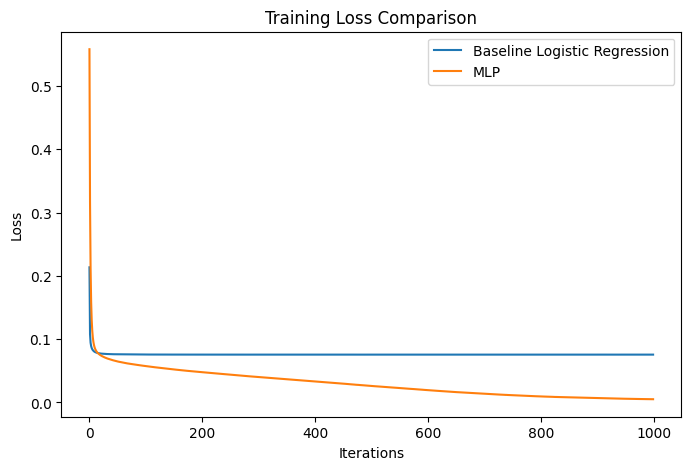

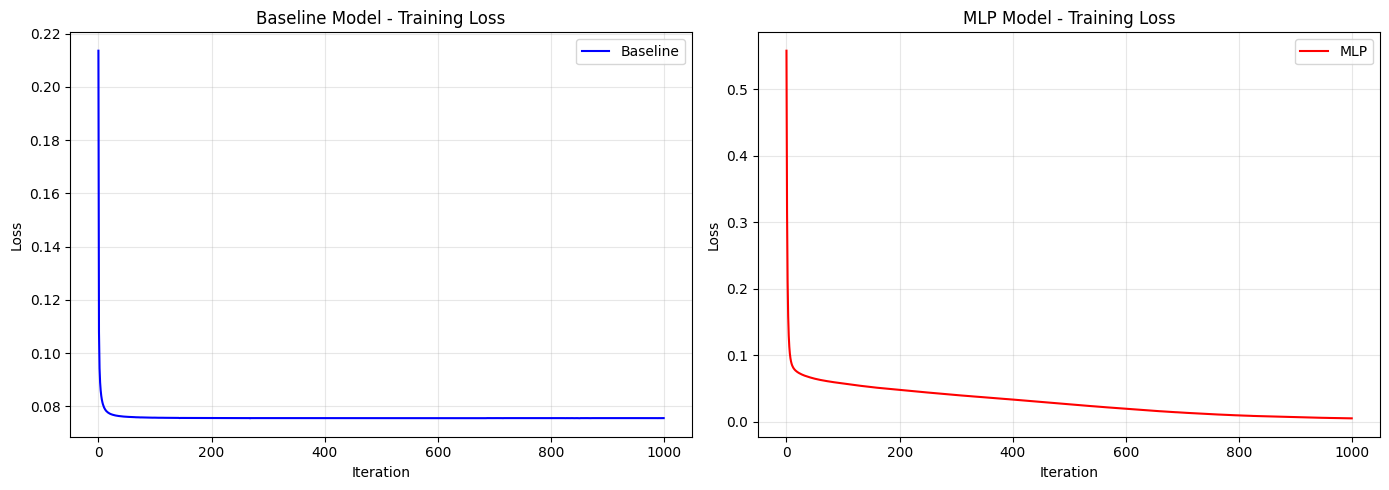

In [ ]:

#Print in a single plot
plt.figure(figsize=(8,5))
plt.plot(baseline_model.loss_history, label="Baseline Logistic Regression")
plt.plot(mlp.loss_history, label="MLP")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()


#Print as seperate plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


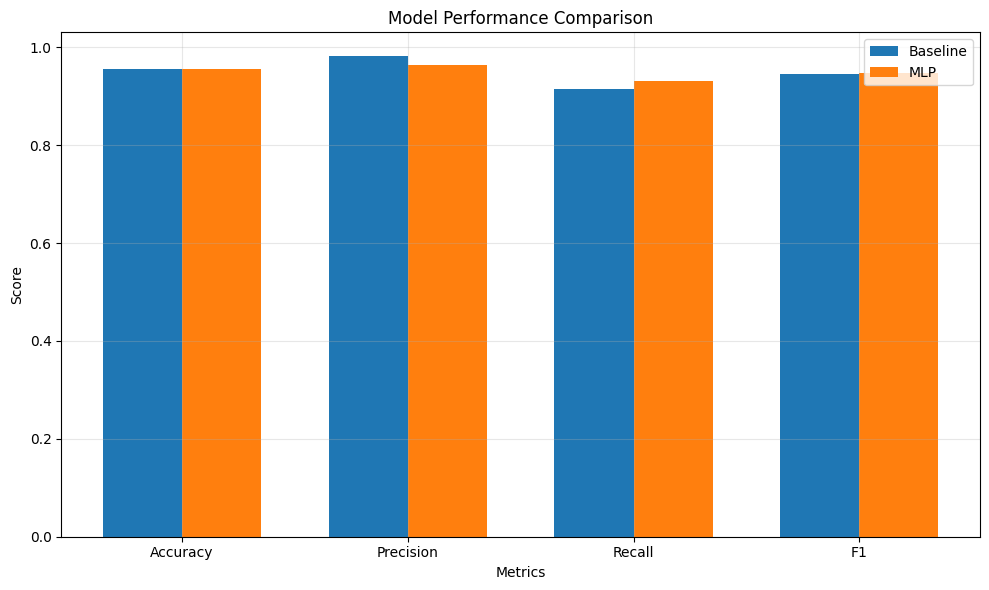

In [ ]:
# 2. Performance comparison bar chart
# Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))

# Example:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [baseline_metrics[m] for m in metrics]
mlp_scores = [mlp_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 7: Analysis and Discussion



Using a stochastic Gradient Descent for MLP has helped in reducing the loss a MLP trained model.
MLP Model do better than Baseline model.

In [ ]:



analysis_text = """
  In this experiment, both a baseline Logistic Regression model and a Multi-Layer Perceptron (MLP) were implemented and evaluated on the Breast Cancer Wisconsin dataset. The goal was to compare a simple linear model with a deeper neural network in terms of performance, learning behavior, and computational cost. Based on the results, the MLP slightly outperformed the baseline model across most evaluation metrics. The baseline model achieved an accuracy of approximately 95.62%, precision of 98.15%, recall of 91.37%, and an F1-score of 94.64%. In comparison, the MLP achieved the same accuracy of 95.62% but improved recall to 93.10% and F1-score to 94.74%, indicating a better balance between precision and recall.
  The improved performance of the MLP can be attributed to its ability to learn non-linear decision boundaries using multiple hidden layers and nonlinear activation functions. While logistic regression assumes a linear relationship between features and the target, the MLP can capture more complex patterns present in the dataset. This is particularly beneficial in medical datasets, where relationships between features are rarely purely linear.

  However, this improvement comes at a computational cost. The baseline model completed training in approximately 9 seconds, while the MLP required around 73 seconds due to the iterative forward and backward propagation steps and the use of stochastic gradient descent. Additionally, the MLP required careful tuning of hyperparameters such as learning rate, number of hidden layers, and early stopping to avoid overfitting.

  One interesting observation is that despite the added complexity, the performance improvement was marginal. This suggests that the dataset is relatively well-structured and nearly linearly separable, making logistic regression a strong baseline. Overall, this experiment highlights the trade-off between model simplicity and expressive power, and demonstrates that while neural networks can provide performance gains, simpler models can often be sufficient and more efficient for structured tabular data.
"""


print(f"Analysis word count: {len(analysis_text.split())} words")
print (analysis_text)
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")


Analysis word count: 301 words

  In this experiment, both a baseline Logistic Regression model and a Multi-Layer Perceptron (MLP) were implemented and evaluated on the Breast Cancer Wisconsin dataset. The goal was to compare a simple linear model with a deeper neural network in terms of performance, learning behavior, and computational cost. Based on the results, the MLP slightly outperformed the baseline model across most evaluation metrics. The baseline model achieved an accuracy of approximately 95.62%, precision of 98.15%, recall of 91.37%, and an F1-score of 94.64%. In comparison, the MLP achieved the same accuracy of 95.62% but improved recall to 93.10% and F1-score to 94.74%, indicating a better balance between precision and recall.
  The improved performance of the MLP can be attributed to its ability to learn non-linear decision boundaries using multiple hidden layers and nonlinear activation functions. While logistic regression assumes a linear relationship between features 

---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [ ]:
def to_python_type(x):
    if isinstance(x, (int, float, str, bool)):
        return x
    try:
        return x.item()
    except:
        return x


def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': to_python_type(n_samples),
        'n_features': to_python_type(n_features),
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': to_python_type(train_samples),
        'test_samples': to_python_type(test_samples),
        'train_test_ratio': to_python_type(train_test_ratio),

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.01,
            'n_iterations': 1000,

            'initial_loss': to_python_type(baseline_initial_loss),
            'final_loss': to_python_type(baseline_final_loss),
            'training_time_seconds': to_python_type(baseline_training_time),
            'loss_decreased': to_python_type(baseline_final_loss < baseline_initial_loss),

            'test_accuracy': to_python_type(baseline_metrics['Accuracy']),
            'test_precision': to_python_type(baseline_metrics['Precision']),
            'test_recall': to_python_type(baseline_metrics['Recall']),
            'test_f1': to_python_type(baseline_metrics['F1']),
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2,
            'learning_rate': 0.01,
            'n_iterations': 1000,

            'initial_loss': to_python_type(mlp_initial_loss),
            'final_loss': to_python_type(mlp_final_loss),
            'training_time_seconds': to_python_type(mlp_training_time),
            'loss_decreased': to_python_type(mlp_final_loss < mlp_initial_loss),

            'test_accuracy': to_python_type(mlp_metrics['Accuracy']),
            'test_precision': to_python_type(mlp_metrics['Precision']),
            'test_recall': to_python_type(mlp_metrics['Recall']),
            'test_f1': to_python_type(mlp_metrics['F1']),
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [ ]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Original)",
  "dataset_source": "UCI Machine Learning Repository",
  "n_samples": 683,
  "n_features": 9,
  "problem_type": "binary_classification",
  "problem_statement": "The objective of this project is to build a machine learning model that can accurately classify breast cancer tumors as malignant or benign using diagnostic features from the Breast Cancer Wisconsin dataset. Early and accurate classification is critical in medical applications to reduce false negatives and improve patient outcomes. Both a baseline logistic regression model and a multi-layer perceptron (MLP) were implemented from scratch to compare performance, learning behavior, and computational cost.",
  "primary_metric": "Recall",
  "metric_justification": "Recall is chosen as the primary evaluation metric because, in medical diagnosis problems, false negatives are more dangerous than false positives. Missing a malignant tumor can have sever

/tmp/ipython-input-1235723868.py:20: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif (v == 0 or v == "" or v == 0.0 or v == []) and \


---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **